# Final Project - Phân lớp dữ liệu Bank Note Authentication

**Môn:** Cơ sở Trí tuệ Nhân tạo  
**Chủ đề:** Binary Classification với `banknote_authentication.csv`  
**Nhóm:** 4 sinh viên  
**Thành viên:** *(điền sau)*  
**Giảng viên hướng dẫn:** *(điền sau)*  

Notebook này được viết theo phong cách gần giống notebook mẫu `Lab07_Pima_Classification.ipynb`, gồm:
- phần mô tả bài toán
- phân tích dữ liệu (EDA)
- tiền xử lý dữ liệu
- chia train/test theo tỉ lệ 70/30 với `random_state = 42`
- đánh giá 10 thuật toán classification bằng `5-fold cross validation`
- so sánh dữ liệu thô / Min-Max / Standard
- tuning siêu tham số cho **KNN** và **SVM**
- chọn mô hình cuối cùng và đánh giá trên tập test

## 1. Ghi chú về nguồn dữ liệu

Theo file yêu cầu đồ án, nhóm chọn dataset **Bank Note Authentication** trong danh sách các bài toán **Binary Classification**.

Bộ dữ liệu này mô tả các đặc trưng được trích xuất từ ảnh tiền giấy bằng **Wavelet Transform**, gồm 4 thuộc tính liên tục:
- `variance`
- `skewness`
- `curtosis`
- `entropy`

Biến mục tiêu là:
- `class = 0`
- `class = 1`

Notebook ưu tiên đọc dữ liệu từ file CSV cục bộ trong thư mục dự án hoặc thư mục dataset đã giải nén.

## 2. Ý nghĩa bài toán

### Input
4 thuộc tính đầu vào:
- `variance`: phương sai của ảnh sau biến đổi Wavelet
- `skewness`: độ lệch
- `curtosis`: độ nhọn
- `entropy`: entropy của ảnh

### Output
- `class = 0` hoặc `class = 1`

### Mục tiêu
Xây dựng mô hình học máy có khả năng phân loại mẫu tiền giấy vào một trong hai lớp dựa trên 4 đặc trưng đầu vào.

### Độ đo đánh giá
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

### Câu hỏi nghiên cứu
1. Dữ liệu thô, Min-Max hay Standard cho kết quả tốt hơn?
2. Trong 10 thuật toán classification, mô hình nào nổi bật nhất trên bộ dữ liệu này?
3. Việc loại bỏ bản ghi trùng lặp có giúp dữ liệu sạch hơn không?
4. Tuning cho KNN và SVM có cải thiện được hiệu năng hay không?

## 3. Import thư viện

Phần này import các thư viện cần thiết cho:
- xử lý dữ liệu
- trực quan hóa
- chia train/test
- cross validation 5-fold
- huấn luyện 10 mô hình classification
- tuning siêu tham số

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

### Thiết lập thư mục dự án và nơi lưu kết quả

Cell này giúp notebook:
- tự nhận diện **thư mục gốc của đồ án**
- tự tạo đúng các thư mục con trong **`07_Ket_qua`**
- lưu lại **hình ảnh, bảng biểu và mô hình** để tiện chèn vào báo cáo và slide

In [2]:
def find_project_root():
    cwd = Path.cwd().resolve()
    search_roots = [cwd, *cwd.parents, Path("/mnt/data/DoAn_CoSoTriTueNhanTao_Banknote")]

    for root in search_roots:
        if (root / "02_Du_lieu").exists() and (root / "07_Ket_qua").exists():
            return root

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc của đồ án. "
        "Hãy mở notebook trong cây thư mục DoAn_CoSoTriTueNhanTao_Banknote."
    )

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "02_Du_lieu"
RESULT_ROOT = PROJECT_ROOT / "07_Ket_qua"

FIG_DIR = RESULT_ROOT / "01_Hinh_anh"
TABLE_DIR = RESULT_ROOT / "02_Bang_bieu"
MODEL_DIR = RESULT_ROOT / "03_Mo_hinh"

for folder in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def save_table(df, filename):
    csv_path = TABLE_DIR / f"{filename}.csv"
    xlsx_path = TABLE_DIR / f"{filename}.xlsx"
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    df.to_excel(xlsx_path, index=False)
    print(f"Đã lưu bảng: {csv_path.name} và {xlsx_path.name}")

def save_figure(filename):
    output_path = FIG_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Đã lưu hình: {output_path.name}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("RESULT_ROOT :", RESULT_ROOT)

PROJECT_ROOT: C:\Users\phuch\OneDrive\Desktop\DoAn_CoSoTriTueNhanTao_Banknote
DATA_ROOT   : C:\Users\phuch\OneDrive\Desktop\DoAn_CoSoTriTueNhanTao_Banknote\02_Du_lieu
RESULT_ROOT : C:\Users\phuch\OneDrive\Desktop\DoAn_CoSoTriTueNhanTao_Banknote\07_Ket_qua


## 4. Đọc dữ liệu

Lưu ý:
- file `banknote_authentication.csv` **không có header**
- notebook sẽ gán tên cột thủ công
- notebook sẽ tự dò nhiều vị trí file để tiện chạy lại ở các môi trường khác nhau

In [3]:
def find_banknote_path():
    candidates = [
        PROJECT_ROOT / "03_Notebook" / "banknote_authentication.csv",
        PROJECT_ROOT / "02_Du_lieu" / "01_Dataset_da_chon_banknote" / "banknote_authentication.csv",
        PROJECT_ROOT / "02_Du_lieu" / "00_Toan_bo_datasets" / "banknote_authentication.csv",
        Path("banknote_authentication.csv"),
        Path("../02_Du_lieu/01_Dataset_da_chon_banknote/banknote_authentication.csv"),
        Path("../02_Du_lieu/00_Toan_bo_datasets/banknote_authentication.csv"),
        Path("/mnt/data/banknote_authentication.csv"),
        Path("/mnt/data/DoAn_CoSoTriTueNhanTao_Banknote/02_Du_lieu/01_Dataset_da_chon_banknote/banknote_authentication.csv"),
        Path("/mnt/data/DoAn_CoSoTriTueNhanTao_Banknote/02_Du_lieu/00_Toan_bo_datasets/banknote_authentication.csv")
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    raise FileNotFoundError(
        "Không tìm thấy file banknote_authentication.csv. "
        "Hãy kiểm tra lại cây thư mục dữ liệu trong 02_Du_lieu."
    )

column_names = ["variance", "skewness", "curtosis", "entropy", "class"]

data_path = find_banknote_path()
df = pd.read_csv(data_path, header=None, names=column_names)

print("Đã đọc dữ liệu từ:", data_path)
display(df.head())

Đã đọc dữ liệu từ: C:\Users\phuch\OneDrive\Desktop\DoAn_CoSoTriTueNhanTao_Banknote\02_Du_lieu\01_Dataset_da_chon_banknote\banknote_authentication.csv


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 5. Kiểm tra kích thước dữ liệu

`shape` cho biết số dòng và số cột của bộ dữ liệu ban đầu.

In [4]:
df.shape

(1372, 5)

## 6. Kiểm tra thông tin chi tiết

`info()` giúp kiểm tra:
- kiểu dữ liệu
- số lượng giá trị không rỗng
- cấu trúc tổng quát của dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


## 7. Thống kê mô tả dữ liệu

`describe()` cho biết:
- mean
- std
- min / max
- các phân vị

Đây là bước cơ bản để nhìn nhanh phân bố số liệu của từng thuộc tính.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


## 8. Kiểm tra giá trị thiếu

Vì nhiều mô hình không xử lý trực tiếp missing values, ta cần kiểm tra sớm ở bước này.

In [7]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

## 9. Kiểm tra dữ liệu trùng lặp

Các dòng trùng lặp có thể làm sai lệch thống kê và làm tăng nguy cơ đánh giá quá lạc quan nếu chúng rơi vào cả train lẫn test.

In [8]:
duplicate_count = df.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated()].head())

Số dòng trùng lặp: 24


,variance,skewness,curtosis,entropy,class
47,-0.7869,9.5663,-3.7867,-7.5034,0
139,-0.2062,9.2207,-3.7044,-6.8103,0
190,0.9297,-3.7971,4.6429,-0.2957,0
195,-1.8584,7.8860,-1.6643,-1.8384,0
226,0.5706,-0.0248,1.2421,-0.5621,0


## 10. Loại bỏ các dòng trùng lặp

Vì dataset có tồn tại bản ghi lặp lại, ta loại bỏ chúng trước khi chia train/test để dữ liệu sạch hơn.

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Kích thước dữ liệu sau khi loại bỏ duplicate:", df.shape)
df.head()

Kích thước dữ liệu sau khi loại bỏ duplicate: (1348, 5)


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## 11. Phân bố lớp mục tiêu

Biểu đồ này cho thấy số lượng mẫu ở mỗi lớp.

Bước này giúp đánh giá xem dữ liệu có mất cân bằng mạnh hay không.

class
0    738
1    610
Name: count, dtype: int64

Đã lưu hình: phan_bo_lop_muc_tieu.png


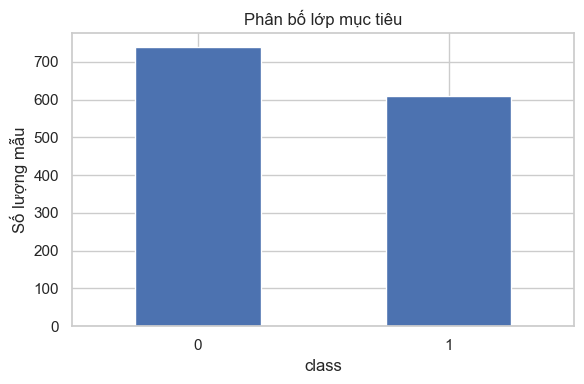

Đã lưu bảng: phan_bo_lop_muc_tieu.csv và phan_bo_lop_muc_tieu.xlsx
Tỷ lệ lớp:
class
0    0.5475
1    0.4525
Name: count, dtype: float64


In [10]:
class_counts = df["class"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Phân bố lớp mục tiêu")
plt.xlabel("class")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=0)
plt.tight_layout()
save_figure("phan_bo_lop_muc_tieu.png")
plt.show()

class_distribution_df = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "ratio": (class_counts.values / len(df)).round(4)
})
save_table(class_distribution_df, "phan_bo_lop_muc_tieu")

print("Tỷ lệ lớp:")
print((class_counts / len(df)).round(4))

## 12. Histogram phân bố dữ liệu

Histogram giúp quan sát:
- mức độ lệch của phân phối
- khoảng giá trị của từng thuộc tính
- khả năng xuất hiện outlier

Đã lưu hình: histogram_phan_bo_du_lieu.png


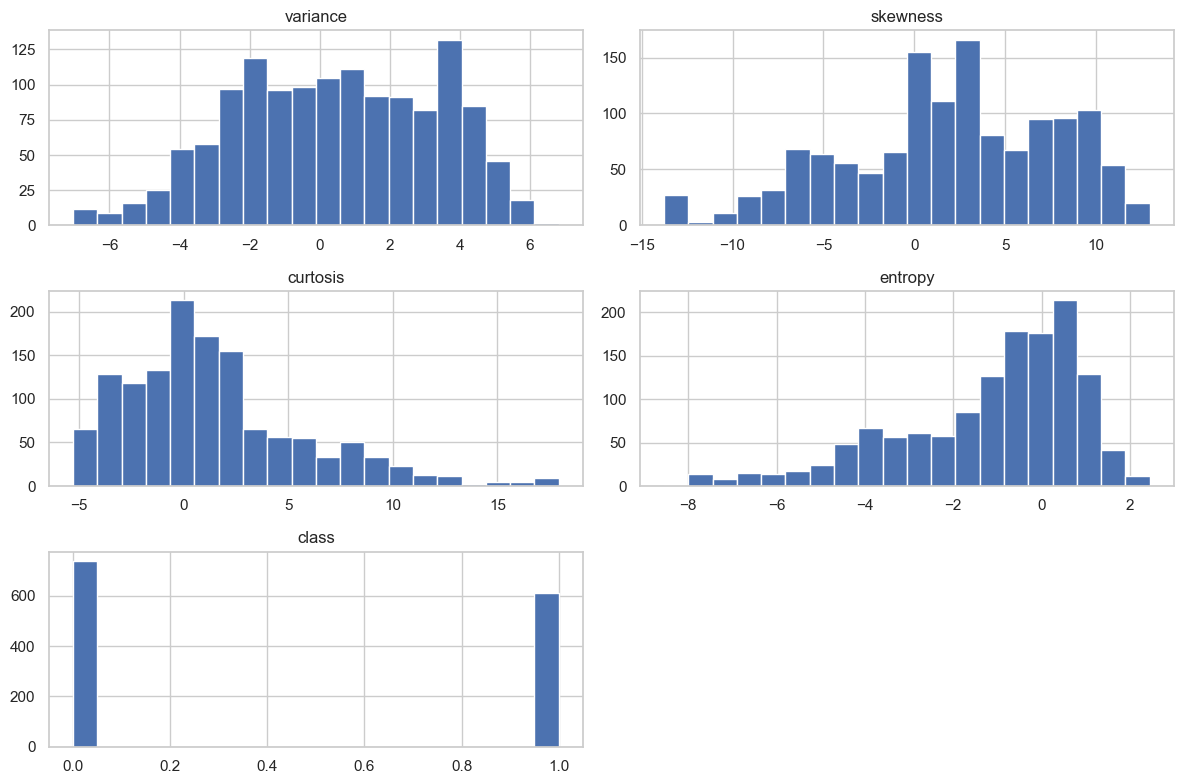

In [11]:
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
save_figure("histogram_phan_bo_du_lieu.png")
plt.show()

## 13. Phát hiện ngoại lệ bằng boxplot

Boxplot giúp nhận biết nhanh các thuộc tính có nhiều giá trị bất thường hoặc phân bố lệch.

Đã lưu hình: boxplot_cac_thuoc_tinh.png


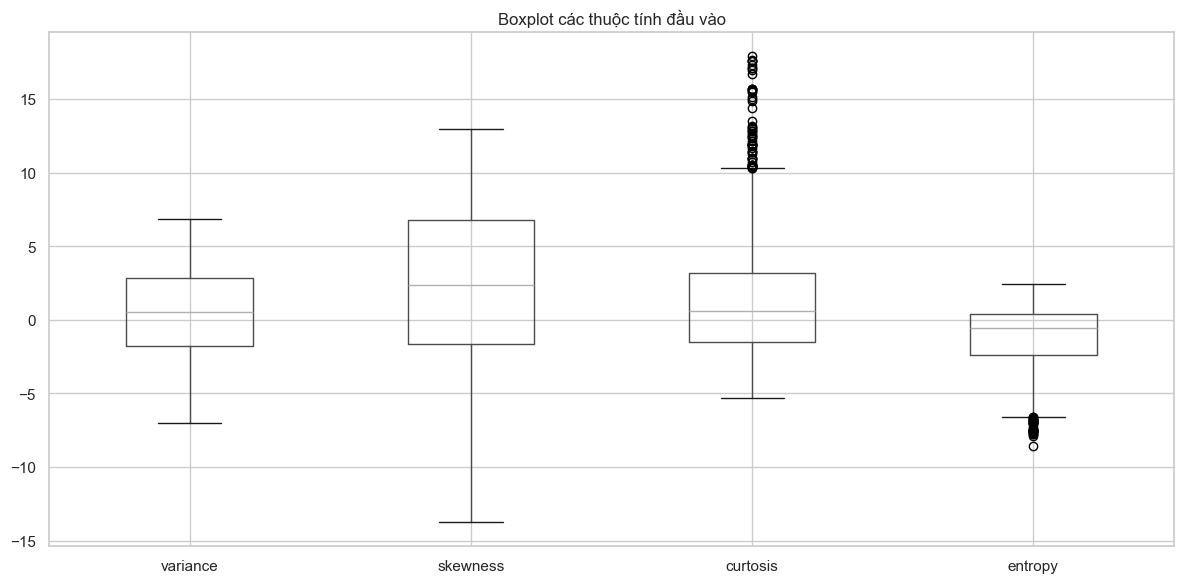

In [12]:
plt.figure(figsize=(12, 6))
df.drop(columns=["class"]).boxplot(rot=0)
plt.title("Boxplot các thuộc tính đầu vào")
plt.tight_layout()
save_figure("boxplot_cac_thuoc_tinh.png")
plt.show()

## 14. Phân tích tương quan giữa các biến

Heatmap cho thấy mức độ tương quan tuyến tính giữa các thuộc tính và biến mục tiêu `class`.

Đã lưu hình: heatmap_tuong_quan.png


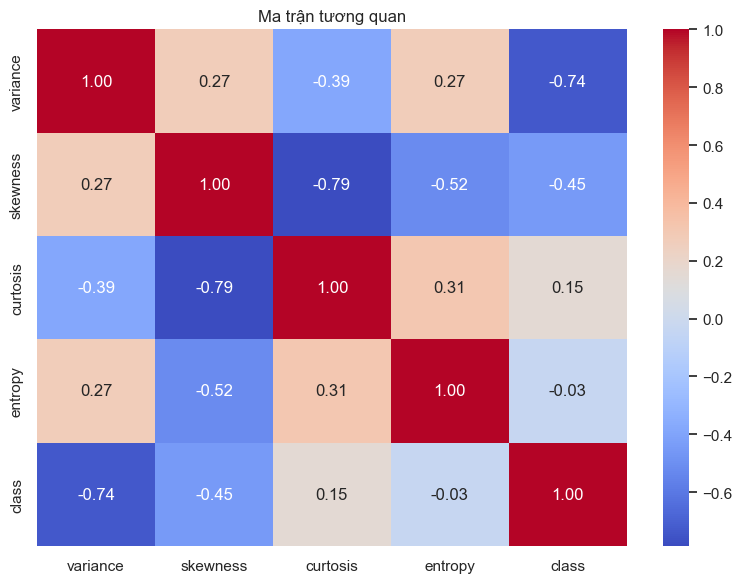

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan")
plt.tight_layout()
save_figure("heatmap_tuong_quan.png")
plt.show()

## 15. Nhận xét nhanh sau EDA

Một số quan sát quan trọng thường thấy ở bộ dữ liệu này:
- dữ liệu hoàn toàn ở dạng số nên thuận lợi cho các thuật toán trong scikit-learn
- không có missing values gốc
- có một số dòng trùng lặp nên nên loại bỏ trước khi huấn luyện
- các thuộc tính có thang đo khác nhau, vì vậy nên thử thêm **Min-Max Scaling** và **StandardScaler**
- đây là bài toán **binary classification**, do đó rất phù hợp để đánh giá thêm bằng **ROC-AUC**

## 16. Tách `X` và `y`

- `X`: các thuộc tính đầu vào
- `y`: biến mục tiêu `class`

In [14]:
X = df.drop(columns=["class"]).copy()
y = df["class"].copy()

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (1348, 4)
Kích thước y: (1348,)


## 17. Chia dữ liệu train/test theo hold-out 7/3

Theo đúng yêu cầu đồ án:
- `70%` dùng cho huấn luyện
- `30%` dùng cho kiểm tra
- `random_state = 42`

Dùng `stratify=y` để giữ tỉ lệ lớp ổn định giữa train và test.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("\nTỷ lệ lớp train:")
display(y_train.value_counts(normalize=True).sort_index().round(4))
print("Tỷ lệ lớp test:")
display(y_test.value_counts(normalize=True).sort_index().round(4))

Kích thước X_train: (943, 4)
Kích thước X_test : (405, 4)

Tỷ lệ lớp train:


class
0    0.5472
1    0.4528
Name: proportion, dtype: float64

Tỷ lệ lớp test:


class
0    0.5481
1    0.4519
Name: proportion, dtype: float64

## 18. Khởi tạo cross validation và 10 mô hình baseline

Theo file yêu cầu project, phần classification cần dùng 10 thuật toán:
1. KNN
2. Naive Bayes
3. SVM
4. Decision Tree
5. Random Forest
6. AdaBoost
7. Gradient Boosting
8. Linear Discriminant Analysis
9. Multi-layer Perceptron
10. Logistic Regression

Để giống phong cách notebook trước, ta sẽ đánh giá các mô hình trên 3 kiểu dữ liệu:
- `raw`
- `minmax`
- `standard`

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(estimator, preprocess_type="raw"):
    steps = [("imputer", SimpleImputer(strategy="median"))]

    if preprocess_type == "minmax":
        steps.append(("scaler", MinMaxScaler()))
    elif preprocess_type == "standard":
        steps.append(("scaler", StandardScaler()))
    elif preprocess_type != "raw":
        raise ValueError("preprocess_type phải là 'raw', 'minmax' hoặc 'standard'")

    steps.append(("model", estimator))
    return Pipeline(steps)

def get_models(preprocess_type="raw"):
    return {
        "KNN": make_pipeline(KNeighborsClassifier(), preprocess_type),
        "NaiveBayes": make_pipeline(GaussianNB(), preprocess_type),
        "SVM": make_pipeline(SVC(probability=True, random_state=42), preprocess_type),
        "DecisionTree": make_pipeline(DecisionTreeClassifier(random_state=42), preprocess_type),
        "RandomForest": make_pipeline(
            RandomForestClassifier(n_estimators=100, random_state=42), preprocess_type
        ),
        "AdaBoost": make_pipeline(
            AdaBoostClassifier(n_estimators=100, random_state=42), preprocess_type
        ),
        "GradientBoosting": make_pipeline(GradientBoostingClassifier(random_state=42), preprocess_type),
        "LDA": make_pipeline(LinearDiscriminantAnalysis(), preprocess_type),
        "MLP": make_pipeline(
            MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42), preprocess_type
        ),
        "LogisticRegression": make_pipeline(
            LogisticRegression(max_iter=2000, random_state=42), preprocess_type
        )
    }

## 19. Hàm đánh giá trên tập test

Sau khi huấn luyện mô hình, ta đánh giá trên tập test bằng các độ đo:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [17]:
def evaluate_on_test(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_score)
    }

## 20. Thực nghiệm baseline trên 3 kiểu tiền xử lý

Quy trình:
1. dùng `5-fold cross validation` trên tập train
2. fit lại mô hình trên toàn bộ tập train
3. đánh giá trên tập test
4. lưu kết quả để so sánh

**Lưu ý:** trong notebook này đặt `n_jobs=1` để chạy ổn định hơn ở nhiều môi trường.  
Nếu chạy trên máy mạnh hơn, bạn có thể đổi thành `n_jobs=-1`.

In [18]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_results = []

start_time = time.time()

for prep in ["raw", "minmax", "standard"]:
    models = get_models(prep)

    for model_name, pipe in models.items():
        cv_result = cross_validate(
            pipe, X_train, y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1
        )

        pipe.fit(X_train, y_train)
        test_result = evaluate_on_test(pipe, X_test, y_test)

        baseline_results.append({
            "Preprocessing": prep,
            "Model": model_name,
            "CV_Accuracy_Mean": cv_result["test_accuracy"].mean(),
            "CV_Precision_Mean": cv_result["test_precision"].mean(),
            "CV_Recall_Mean": cv_result["test_recall"].mean(),
            "CV_F1_Mean": cv_result["test_f1"].mean(),
            "CV_AUC_Mean": cv_result["test_roc_auc"].mean(),
            "Test_Accuracy": test_result["Accuracy"],
            "Test_Precision": test_result["Precision"],
            "Test_Recall": test_result["Recall"],
            "Test_F1": test_result["F1-score"],
            "Test_AUC": test_result["AUC"]
        })

elapsed = time.time() - start_time
print(f"Thời gian chạy baseline: {elapsed:.2f} giây")

results_df = pd.DataFrame(baseline_results)
results_df_rounded = results_df.copy()

metric_cols = [
    "CV_Accuracy_Mean", "CV_Precision_Mean", "CV_Recall_Mean", "CV_F1_Mean",
    "CV_AUC_Mean", "Test_Accuracy", "Test_Precision", "Test_Recall", "Test_F1", "Test_AUC"
]
results_df_rounded[metric_cols] = results_df_rounded[metric_cols].round(4)

save_table(results_df_rounded, "bang_ket_qua_baseline_day_du")
display(results_df_rounded.head())

Thời gian chạy baseline: 14.62 giây
Đã lưu bảng: bang_ket_qua_baseline_day_du.csv và bang_ket_qua_baseline_day_du.xlsx


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,raw,KNN,0.9968,0.9931,1.0000,0.9965,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
1,raw,NaiveBayes,0.8462,0.8636,0.7845,0.8220,0.9424,0.8691,0.8533,0.8579,0.8556,0.9512
2,raw,SVM,0.9958,0.9909,1.0000,0.9954,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
3,raw,DecisionTree,0.9830,0.9794,0.9836,0.9814,0.9831,0.9926,0.9945,0.9891,0.9918,0.9923
4,raw,RandomForest,0.9873,0.9840,0.9883,0.9860,0.9996,0.9975,0.9946,1.0000,0.9973,1.0000


## 21. Bảng kết quả baseline theo từng kiểu dữ liệu

Ta sắp xếp theo `Test_Accuracy` và `Test_AUC` để dễ quan sát mô hình nổi bật nhất.

In [19]:
for prep in ["raw", "minmax", "standard"]:
    print("=" * 90)
    print(f"KẾT QUẢ BASELINE - {prep.upper()}")
    display(
        results_df_rounded[results_df_rounded["Preprocessing"] == prep]
        .sort_values(by=["Test_Accuracy", "Test_AUC"], ascending=False)
        .reset_index(drop=True)
    )

KẾT QUẢ BASELINE - RAW


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,raw,GradientBoosting,0.9915,0.9842,0.9976,0.9908,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000
1,raw,MLP,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,raw,KNN,0.9968,0.9931,1.0000,0.9965,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
3,raw,SVM,0.9958,0.9909,1.0000,0.9954,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
4,raw,RandomForest,0.9873,0.9840,0.9883,0.9860,0.9996,0.9975,0.9946,1.0000,0.9973,1.0000
5,raw,AdaBoost,0.9947,0.9909,0.9976,0.9942,0.9999,0.9975,0.9946,1.0000,0.9973,0.9998
6,raw,DecisionTree,0.9830,0.9794,0.9836,0.9814,0.9831,0.9926,0.9945,0.9891,0.9918,0.9923
7,raw,LogisticRegression,0.9947,0.9909,0.9976,0.9942,1.0000,0.9901,0.9786,1.0000,0.9892,0.9999
8,raw,LDA,0.9873,0.9736,1.0000,0.9864,1.0000,0.9877,0.9734,1.0000,0.9865,0.9998
9,raw,NaiveBayes,0.8462,0.8636,0.7845,0.8220,0.9424,0.8691,0.8533,0.8579,0.8556,0.9512


KẾT QUẢ BASELINE - MINMAX


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,minmax,GradientBoosting,0.9915,0.9842,0.9976,0.9908,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000
1,minmax,SVM,0.9958,0.9909,1.0000,0.9954,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
2,minmax,RandomForest,0.9873,0.9840,0.9883,0.9860,0.9996,0.9975,0.9946,1.0000,0.9973,1.0000
3,minmax,AdaBoost,0.9947,0.9909,0.9976,0.9942,0.9999,0.9975,0.9946,1.0000,0.9973,0.9998
4,minmax,KNN,0.9958,0.9909,1.0000,0.9954,0.9990,0.9975,0.9946,1.0000,0.9973,0.9977
5,minmax,DecisionTree,0.9830,0.9794,0.9836,0.9814,0.9831,0.9926,0.9945,0.9891,0.9918,0.9923
6,minmax,MLP,0.9926,0.9845,1.0000,0.9920,1.0000,0.9877,0.9734,1.0000,0.9865,1.0000
7,minmax,LDA,0.9873,0.9736,1.0000,0.9864,1.0000,0.9877,0.9734,1.0000,0.9865,0.9998
8,minmax,LogisticRegression,0.9777,0.9776,0.9742,0.9754,0.9985,0.9827,0.9731,0.9891,0.9810,0.9990
9,minmax,NaiveBayes,0.8462,0.8636,0.7845,0.8220,0.9424,0.8691,0.8533,0.8579,0.8556,0.9512


KẾT QUẢ BASELINE - STANDARD


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,standard,GradientBoosting,0.9915,0.9842,0.9976,0.9908,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000
1,standard,SVM,0.9958,0.9909,1.0000,0.9954,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
2,standard,RandomForest,0.9873,0.9840,0.9883,0.9860,0.9996,0.9975,0.9946,1.0000,0.9973,1.0000
3,standard,AdaBoost,0.9947,0.9909,0.9976,0.9942,0.9999,0.9975,0.9946,1.0000,0.9973,0.9998
4,standard,KNN,0.9958,0.9909,1.0000,0.9954,0.9990,0.9975,0.9946,1.0000,0.9973,0.9977
5,standard,DecisionTree,0.9830,0.9794,0.9836,0.9814,0.9831,0.9926,0.9945,0.9891,0.9918,0.9923
6,standard,MLP,0.9958,0.9909,1.0000,0.9954,1.0000,0.9877,0.9734,1.0000,0.9865,1.0000
7,standard,LogisticRegression,0.9926,0.9866,0.9976,0.9919,1.0000,0.9877,0.9734,1.0000,0.9865,0.9999
8,standard,LDA,0.9873,0.9736,1.0000,0.9864,1.0000,0.9877,0.9734,1.0000,0.9865,0.9998
9,standard,NaiveBayes,0.8462,0.8636,0.7845,0.8220,0.9424,0.8691,0.8533,0.8579,0.8556,0.9512


## 22. Tổng hợp mô hình tốt nhất của mỗi kiểu tiền xử lý

Bảng này giúp trả lời nhanh:
- dữ liệu thô tốt hơn hay dữ liệu chuẩn hóa?
- mô hình nào nổi bật nhất trong từng trường hợp?

In [20]:
best_by_prep = (
    results_df_rounded.sort_values(
        by=["Preprocessing", "Test_Accuracy", "Test_AUC"],
        ascending=[True, False, False]
    )
    .groupby("Preprocessing", as_index=False)
    .first()
)

save_table(best_by_prep, "tong_hop_mo_hinh_tot_nhat_theo_tien_xu_ly")
best_by_prep

Đã lưu bảng: tong_hop_mo_hinh_tot_nhat_theo_tien_xu_ly.csv và tong_hop_mo_hinh_tot_nhat_theo_tien_xu_ly.xlsx


,Preprocessing,Model,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,minmax,GradientBoosting,0.9915,0.9842,0.9976,0.9908,0.9993,1.0,1.0,1.0,1.0,1.0
1,raw,GradientBoosting,0.9915,0.9842,0.9976,0.9908,0.9993,1.0,1.0,1.0,1.0,1.0
2,standard,GradientBoosting,0.9915,0.9842,0.9976,0.9908,0.9993,1.0,1.0,1.0,1.0,1.0


## 23. Chọn biến thể tốt nhất của từng thuật toán

Vì mỗi thuật toán được chạy với 3 cách tiền xử lý, ta giữ lại **phiên bản tốt nhất** của từng thuật toán để:
- so sánh công bằng giữa 10 thuật toán
- tìm 2 thuật toán tốt nhất theo từng metric

In [21]:
best_variant_by_model = (
    results_df_rounded.sort_values(
        by=["Model", "Test_Accuracy", "Test_AUC"],
        ascending=[True, False, False]
    )
    .groupby("Model", as_index=False)
    .first()
)

best_variant_by_model_sorted = best_variant_by_model.sort_values(
    by=["Test_Accuracy", "Test_AUC"], ascending=False
).reset_index(drop=True)

save_table(best_variant_by_model_sorted, "bien_the_tot_nhat_cua_tung_thuat_toan")
best_variant_by_model_sorted

Đã lưu bảng: bien_the_tot_nhat_cua_tung_thuat_toan.csv và bien_the_tot_nhat_cua_tung_thuat_toan.xlsx


,Model,Preprocessing,CV_Accuracy_Mean,CV_Precision_Mean,CV_Recall_Mean,CV_F1_Mean,CV_AUC_Mean,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,GradientBoosting,raw,0.9915,0.9842,0.9976,0.9908,0.9993,1.0000,1.0000,1.0000,1.0000,1.0000
1,MLP,raw,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,KNN,raw,0.9968,0.9931,1.0000,0.9965,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
3,RandomForest,raw,0.9873,0.9840,0.9883,0.9860,0.9996,0.9975,0.9946,1.0000,0.9973,1.0000
4,SVM,raw,0.9958,0.9909,1.0000,0.9954,1.0000,0.9975,0.9946,1.0000,0.9973,1.0000
5,AdaBoost,raw,0.9947,0.9909,0.9976,0.9942,0.9999,0.9975,0.9946,1.0000,0.9973,0.9998
6,DecisionTree,raw,0.9830,0.9794,0.9836,0.9814,0.9831,0.9926,0.9945,0.9891,0.9918,0.9923
7,LogisticRegression,raw,0.9947,0.9909,0.9976,0.9942,1.0000,0.9901,0.9786,1.0000,0.9892,0.9999
8,LDA,raw,0.9873,0.9736,1.0000,0.9864,1.0000,0.9877,0.9734,1.0000,0.9865,0.9998
9,NaiveBayes,raw,0.8462,0.8636,0.7845,0.8220,0.9424,0.8691,0.8533,0.8579,0.8556,0.9512


## 24. Tìm 2 thuật toán tốt nhất theo từng độ đo

Yêu cầu này rất hữu ích cho phần thảo luận trong báo cáo:
- top 2 theo Accuracy
- top 2 theo Precision
- top 2 theo Recall
- top 2 theo F1-score
- top 2 theo AUC

In [22]:
top2_tables = {}

metric_map = {
    "Accuracy": "Test_Accuracy",
    "Precision": "Test_Precision",
    "Recall": "Test_Recall",
    "F1-score": "Test_F1",
    "AUC": "Test_AUC"
}

for metric_name, col_name in metric_map.items():
    top2 = (
        best_variant_by_model[["Model", "Preprocessing", col_name]]
        .sort_values(by=col_name, ascending=False)
        .head(2)
        .reset_index(drop=True)
    )
    top2_tables[metric_name] = top2
    save_table(top2, f"top2_theo_{metric_name.lower().replace('-', '_')}")
    print(f"\nTOP 2 THEO {metric_name.upper()}")
    display(top2)

Đã lưu bảng: top2_theo_accuracy.csv và top2_theo_accuracy.xlsx

TOP 2 THEO ACCURACY


,Model,Preprocessing,Test_Accuracy
0,GradientBoosting,raw,1.0
1,MLP,raw,1.0


Đã lưu bảng: top2_theo_precision.csv và top2_theo_precision.xlsx

TOP 2 THEO PRECISION


,Model,Preprocessing,Test_Precision
0,GradientBoosting,raw,1.0
1,MLP,raw,1.0


Đã lưu bảng: top2_theo_recall.csv và top2_theo_recall.xlsx

TOP 2 THEO RECALL


,Model,Preprocessing,Test_Recall
0,AdaBoost,raw,1.0
1,GradientBoosting,raw,1.0


Đã lưu bảng: top2_theo_f1_score.csv và top2_theo_f1_score.xlsx

TOP 2 THEO F1-SCORE


,Model,Preprocessing,Test_F1
0,GradientBoosting,raw,1.0
1,MLP,raw,1.0


Đã lưu bảng: top2_theo_auc.csv và top2_theo_auc.xlsx

TOP 2 THEO AUC


,Model,Preprocessing,Test_AUC
0,GradientBoosting,raw,1.0
1,KNN,raw,1.0


## 25. Trực quan hóa Accuracy của các mô hình baseline

Biểu đồ cột giúp so sánh trực quan giữa các mô hình ở 3 kiểu tiền xử lý khác nhau.

Đã lưu hình: so_sanh_test_accuracy_baseline.png


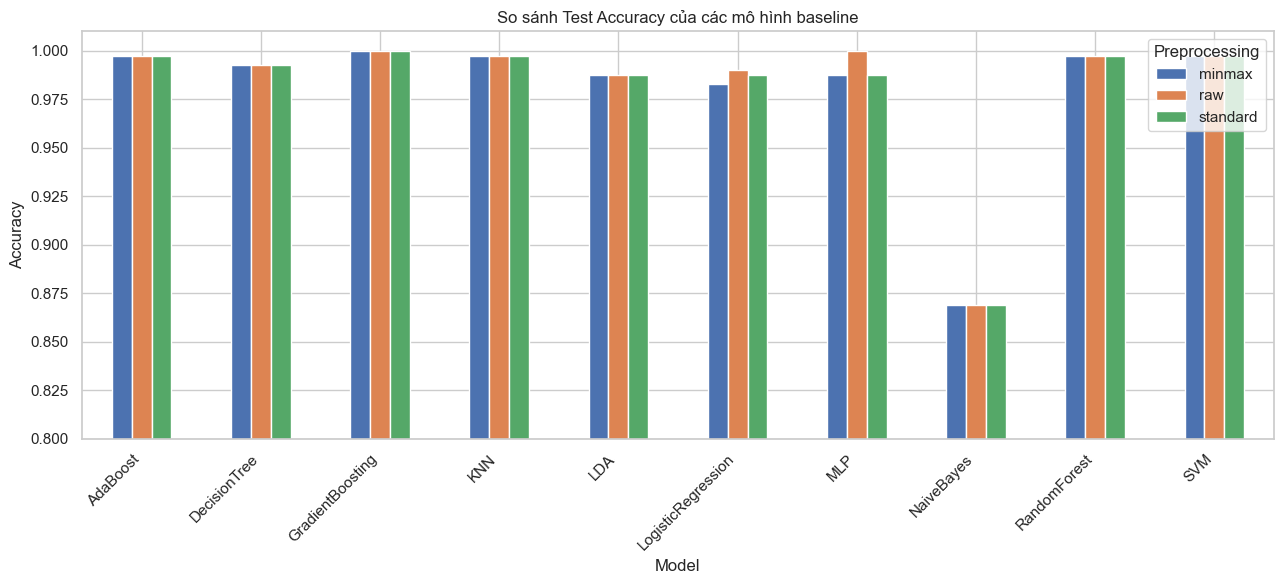

In [23]:
accuracy_pivot = results_df_rounded.pivot(index="Model", columns="Preprocessing", values="Test_Accuracy")
accuracy_pivot.plot(kind="bar", figsize=(13, 6))
plt.xticks(rotation=45, ha="right")
plt.ylim(0.80, 1.01)
plt.title("So sánh Test Accuracy của các mô hình baseline")
plt.ylabel("Accuracy")
plt.tight_layout()
save_figure("so_sanh_test_accuracy_baseline.png")
plt.show()

## 26. Trực quan hóa AUC của các mô hình baseline

AUC đặc biệt quan trọng trong bài toán classification nhị phân vì nó phản ánh khả năng phân tách hai lớp.

Đã lưu hình: so_sanh_test_auc_baseline.png


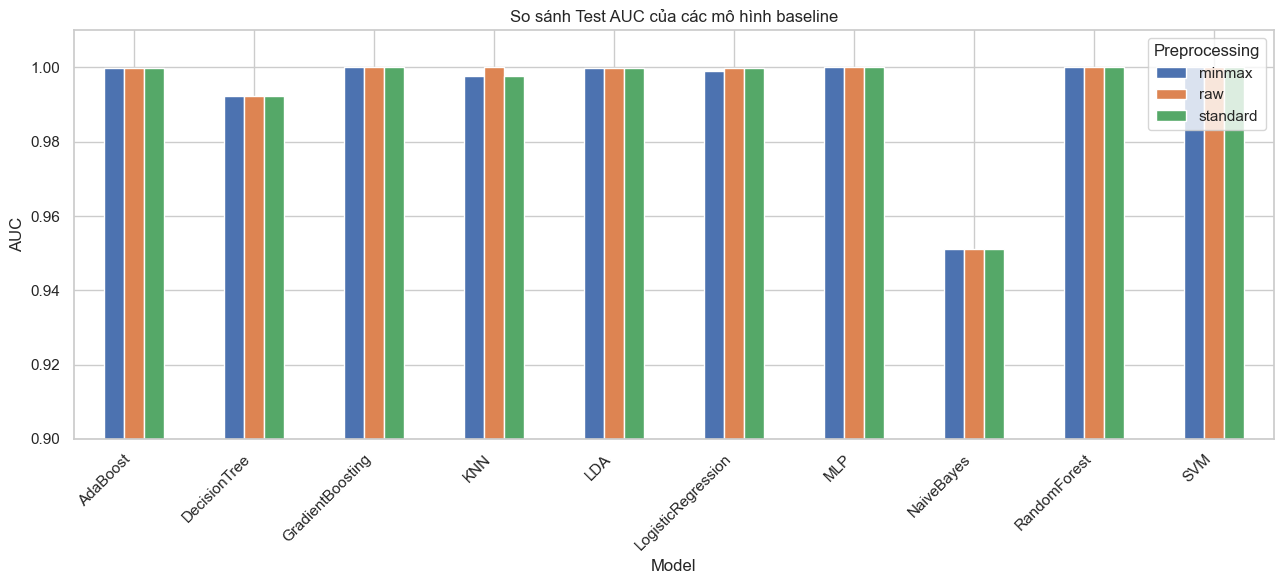

In [24]:
auc_pivot = results_df_rounded.pivot(index="Model", columns="Preprocessing", values="Test_AUC")
auc_pivot.plot(kind="bar", figsize=(13, 6))
plt.xticks(rotation=45, ha="right")
plt.ylim(0.90, 1.01)
plt.title("So sánh Test AUC của các mô hình baseline")
plt.ylabel("AUC")
plt.tight_layout()
save_figure("so_sanh_test_auc_baseline.png")
plt.show()

## 27. Tối ưu siêu tham số cho KNN

Để giữ phong cách tương tự notebook trước, phần tuning tập trung vào:
- **KNN**
- **SVM**

Với KNN:
- mô hình khá nhạy với thang đo
- do đó dùng `StandardScaler`
- dùng `GridSearchCV` với `cv=5`

In [25]:
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=1
)

knn_grid.fit(X_train, y_train)

knn_tuning_df = pd.DataFrame(knn_grid.cv_results_)[[
    "param_model__n_neighbors",
    "param_model__weights",
    "param_model__metric",
    "mean_test_score",
    "rank_test_score"
]].sort_values(by=["rank_test_score", "mean_test_score"], ascending=[True, False]).reset_index(drop=True)

save_table(knn_tuning_df, "ket_qua_tuning_knn")

print("Best params for KNN:")
print(knn_grid.best_params_)
print("Best CV score:", round(knn_grid.best_score_, 4))

Đã lưu bảng: ket_qua_tuning_knn.csv và ket_qua_tuning_knn.xlsx
Best params for KNN:
{'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'distance'}
Best CV score: 0.9979


## 28. Đánh giá KNN tối ưu trên tập test

In [26]:
best_knn = knn_grid.best_estimator_
knn_test_result = evaluate_on_test(best_knn, X_test, y_test)

knn_test_df = pd.DataFrame([knn_test_result], index=["Best KNN"]).round(4).reset_index().rename(columns={"index": "Model"})
save_table(knn_test_df, "danh_gia_knn_toi_uu_tren_test")
knn_test_df

Đã lưu bảng: danh_gia_knn_toi_uu_tren_test.csv và danh_gia_knn_toi_uu_tren_test.xlsx


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Best KNN,0.9975,0.9946,1.0,0.9973,0.9977


## 29. Tối ưu siêu tham số cho SVM

SVM cũng là mô hình nhạy với chuẩn hóa dữ liệu, nên ta dùng:
- `StandardScaler`
- `GridSearchCV`
- các siêu tham số: `C`, `kernel`, `gamma`

In [27]:
svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svm_param_grid = {
    "model__C": [0.1, 1, 10, 50, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=1
)

svm_grid.fit(X_train, y_train)

svm_tuning_df = pd.DataFrame(svm_grid.cv_results_)[[
    "param_model__C",
    "param_model__kernel",
    "param_model__gamma",
    "mean_test_score",
    "rank_test_score"
]].sort_values(by=["rank_test_score", "mean_test_score"], ascending=[True, False]).reset_index(drop=True)

save_table(svm_tuning_df, "ket_qua_tuning_svm")

print("Best params for SVM:")
print(svm_grid.best_params_)
print("Best CV score:", round(svm_grid.best_score_, 4))

Đã lưu bảng: ket_qua_tuning_svm.csv và ket_qua_tuning_svm.xlsx
Best params for SVM:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV score: 1.0


## 30. Đánh giá SVM tối ưu trên tập test

In [28]:
best_svm = svm_grid.best_estimator_
svm_test_result = evaluate_on_test(best_svm, X_test, y_test)

svm_test_df = pd.DataFrame([svm_test_result], index=["Best SVM"]).round(4).reset_index().rename(columns={"index": "Model"})
save_table(svm_test_df, "danh_gia_svm_toi_uu_tren_test")
svm_test_df

Đã lưu bảng: danh_gia_svm_toi_uu_tren_test.csv và danh_gia_svm_toi_uu_tren_test.xlsx


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Best SVM,1.0,1.0,1.0,1.0,1.0


## 31. So sánh mô hình tốt nhất sau tuning

Bảng này so sánh:
- mô hình baseline tốt nhất trên tập test
- KNN sau tuning
- SVM sau tuning

In [29]:
baseline_best_idx = results_df.sort_values(
    by=["Test_Accuracy", "Test_AUC"], ascending=False
).index[0]

baseline_best_row = results_df.loc[baseline_best_idx]

final_compare_df = pd.DataFrame([
    {
        "Model": f"Baseline best: {baseline_best_row['Model']} ({baseline_best_row['Preprocessing']})",
        "Accuracy": baseline_best_row["Test_Accuracy"],
        "Precision": baseline_best_row["Test_Precision"],
        "Recall": baseline_best_row["Test_Recall"],
        "F1-score": baseline_best_row["Test_F1"],
        "AUC": baseline_best_row["Test_AUC"]
    },
    {
        "Model": "Tuned KNN (standard)",
        **knn_test_result
    },
    {
        "Model": "Tuned SVM (standard)",
        **svm_test_result
    }
]).round(4)

final_compare_df = final_compare_df.sort_values(by=["Accuracy", "AUC"], ascending=False).reset_index(drop=True)
save_table(final_compare_df, "so_sanh_cac_mo_hinh_tot_nhat_sau_tuning")
final_compare_df

Đã lưu bảng: so_sanh_cac_mo_hinh_tot_nhat_sau_tuning.csv và so_sanh_cac_mo_hinh_tot_nhat_sau_tuning.xlsx


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline best: GradientBoosting (raw),1.0000,1.0000,1.0,1.0000,1.0000
1,Tuned SVM (standard),1.0000,1.0000,1.0,1.0000,1.0000
2,Tuned KNN (standard),0.9975,0.9946,1.0,0.9973,0.9977


## 32. Chọn mô hình cuối cùng tốt nhất

Tiêu chí chọn:
1. ưu tiên `Accuracy` cao nhất
2. nếu bằng nhau, ưu tiên `AUC` cao hơn

In [30]:
candidate_models = {
    f"Baseline best: {baseline_best_row['Model']} ({baseline_best_row['Preprocessing']})":
        get_models(baseline_best_row["Preprocessing"])[baseline_best_row["Model"]],
    "Tuned KNN (standard)": best_knn,
    "Tuned SVM (standard)": best_svm
}

baseline_key = f"Baseline best: {baseline_best_row['Model']} ({baseline_best_row['Preprocessing']})"
candidate_models[baseline_key].fit(X_train, y_train)

final_scores = []
for name, model in candidate_models.items():
    metrics = evaluate_on_test(model, X_test, y_test)
    final_scores.append({"Model": name, **metrics})

final_scores_df = pd.DataFrame(final_scores).round(4).sort_values(
    by=["Accuracy", "AUC"], ascending=False
).reset_index(drop=True)

save_table(final_scores_df, "bang_diem_cuoi_cung_cua_cac_mo_hinh_ung_vien")
final_scores_df

Đã lưu bảng: bang_diem_cuoi_cung_cua_cac_mo_hinh_ung_vien.csv và bang_diem_cuoi_cung_cua_cac_mo_hinh_ung_vien.xlsx


,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Baseline best: GradientBoosting (raw),1.0000,1.0000,1.0,1.0000,1.0000
1,Tuned SVM (standard),1.0000,1.0000,1.0,1.0000,1.0000
2,Tuned KNN (standard),0.9975,0.9946,1.0,0.9973,0.9977


## 33. Ma trận nhầm lẫn và classification report của mô hình cuối cùng

Mô hình được chọn: Baseline best: GradientBoosting (raw)

Confusion Matrix:
[[222   0]
 [  0 183]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       222
           1     1.0000    1.0000    1.0000       183

    accuracy                         1.0000       405
   macro avg     1.0000    1.0000    1.0000       405
weighted avg     1.0000    1.0000    1.0000       405

Đã lưu bảng: confusion_matrix_mo_hinh_cuoi_cung.csv và confusion_matrix_mo_hinh_cuoi_cung.xlsx
Đã lưu hình: confusion_matrix_mo_hinh_cuoi_cung.png


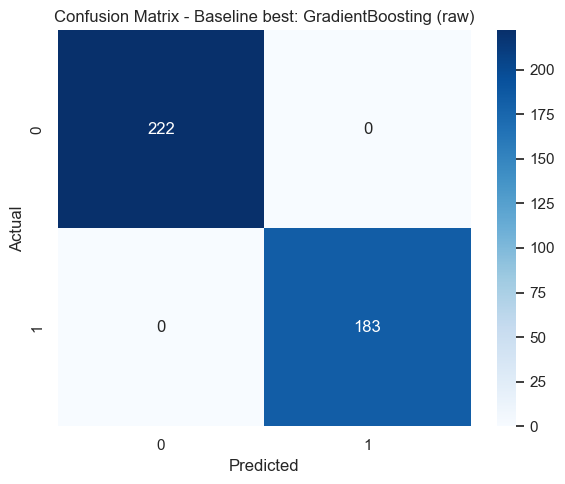

Đã lưu mô hình tốt nhất vào thư mục 03_Mo_hinh.


In [31]:
best_model_name = final_scores_df.loc[0, "Model"]
best_model = candidate_models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
print("Mô hình được chọn:", best_model_name)
print()
print("Confusion Matrix:")
print(cm)
print()
report_text = classification_report(y_test, y_pred_best, digits=4)
print("Classification Report:")
print(report_text)

with open(TABLE_DIR / "classification_report_mo_hinh_cuoi_cung.txt", "w", encoding="utf-8") as f:
    f.write(f"Mô hình được chọn: {best_model_name}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification Report:\n")
    f.write(report_text)

cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
save_table(cm_df.reset_index().rename(columns={"index": "Actual/Pred"}), "confusion_matrix_mo_hinh_cuoi_cung")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
save_figure("confusion_matrix_mo_hinh_cuoi_cung.png")
plt.show()

joblib.dump(best_model, MODEL_DIR / "best_model_banknote.pkl")
print("Đã lưu mô hình tốt nhất vào thư mục 03_Mo_hinh.")

## 34. Đường cong ROC của mô hình cuối cùng

ROC curve cho thấy khả năng phân tách giữa hai lớp của mô hình.  
AUC càng cao thì mô hình càng tốt trong việc phân biệt hai lớp.

Đã lưu hình: roc_curve_mo_hinh_cuoi_cung.png


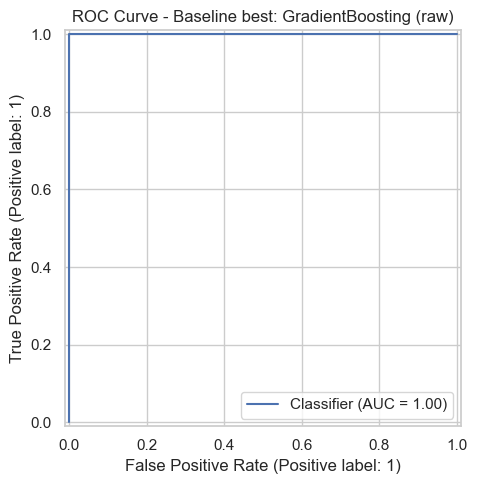

Final AUC: 1.0


In [32]:
if hasattr(best_model, "predict_proba"):
    y_score_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_score_best = best_model.decision_function(X_test)

RocCurveDisplay.from_predictions(y_test, y_score_best)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
save_figure("roc_curve_mo_hinh_cuoi_cung.png")
plt.show()

final_auc = roc_auc_score(y_test, y_score_best)
print("Final AUC:", round(final_auc, 4))

## 35. Nhận xét kết quả

Từ các kết quả thu được, có thể rút ra một số nhận xét:

- Bộ dữ liệu Bank Note Authentication tương đối “sạch”, không có missing values gốc và chỉ có 4 thuộc tính đầu vào.
- Tuy nhiên, dữ liệu có tồn tại một số bản ghi trùng lặp, vì vậy việc loại bỏ duplicate là hợp lý.
- Nhiều mô hình có thể đạt kết quả rất cao trên bộ dữ liệu này, cho thấy hai lớp có mức độ phân tách khá tốt.
- Các mô hình nhạy với thang đo như **KNN**, **SVM** và **MLP** thường nên được thử thêm với `MinMaxScaler` hoặc `StandardScaler`.
- Bước tuning giúp chọn được cấu hình tốt hơn và hỗ trợ phần “optimisation” đúng theo tinh thần đề tài.

# 36. Kết luận

Notebook đã thực hiện đầy đủ quy trình cho bài toán phân lớp dữ liệu **Bank Note Authentication**:

1. xác định ý nghĩa bài toán  
2. đọc và chuẩn hóa dữ liệu  
3. thực hiện EDA  
4. xử lý dữ liệu trùng lặp  
5. chia train/test theo tỉ lệ 70/30 với `random_state = 42`  
6. đánh giá 10 thuật toán classification bằng `5-fold cross validation`  
7. so sánh dữ liệu thô / Min-Max / Standard  
8. tuning siêu tham số cho KNN và SVM  
9. chọn mô hình cuối cùng và đánh giá trên tập test  

Kết quả của notebook có thể dùng trực tiếp để:
- làm phần **thực nghiệm** trong báo cáo Word
- lấy bảng số liệu cho phần **so sánh mô hình**
- chụp biểu đồ cho slide PowerPoint
- viết phần **nhận xét, thảo luận và kết luận**